In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
dataroot = Path("/content/drive/MyDrive/chess-project")  # <-- adjust if needed

print((dataroot/"annotations.json").exists())
print((dataroot/"images").is_dir())
print((dataroot/"piece_dataset.py").exists())

Mounted at /content/drive
True
True
True


In [2]:
# Import the dataset class
import sys
sys.path.append(str(dataroot))  # Add the folder to Python path

from piece_dataset import PieceClassificationDataset, get_default_transforms

# Test loading the train split
dataset = PieceClassificationDataset(
    dataroot=dataroot,
    split="train",
    transform=get_default_transforms(train=True),
    use_chessred2k_split=True
)

# Show one sample
image, label = dataset[0]
print(f"\nSample loaded successfully!")
print(f"Image shape: {image.shape}")
print(f"Label: {label}")

[PieceClassificationDataset] train split:
  1442 images
  30723 piece samples
  Class distribution:
     0 white-pawn          :  7653 samples
     1 white-rook          :  2250 samples
     2 white-knight        :  1423 samples
     3 white-bishop        :  1607 samples
     4 white-queen         :   838 samples
     5 white-king          :  1442 samples
     6 black-pawn          :  8059 samples
     7 black-rook          :  2293 samples
     8 black-knight        :  1276 samples
     9 black-bishop        :  1578 samples
    10 black-queen         :   862 samples
    11 black-king          :  1442 samples

Sample loaded successfully!
Image shape: torch.Size([3, 224, 224])
Label: 7


In [3]:
train_data = PieceClassificationDataset(
    dataroot=dataroot,
    split="train",
    transform=get_default_transforms(train=True),
    use_chessred2k_split=True
)

val_data = PieceClassificationDataset(
    dataroot=dataroot,
    split = "val",
    transform=get_default_transforms(train=True),
    use_chessred2k_split=True
)


test_data = PieceClassificationDataset(
    dataroot=dataroot,
    split = "test",
    transform=get_default_transforms(train=True),
    use_chessred2k_split=True
)

[PieceClassificationDataset] train split:
  1442 images
  30723 piece samples
  Class distribution:
     0 white-pawn          :  7653 samples
     1 white-rook          :  2250 samples
     2 white-knight        :  1423 samples
     3 white-bishop        :  1607 samples
     4 white-queen         :   838 samples
     5 white-king          :  1442 samples
     6 black-pawn          :  8059 samples
     7 black-rook          :  2293 samples
     8 black-knight        :  1276 samples
     9 black-bishop        :  1578 samples
    10 black-queen         :   862 samples
    11 black-king          :  1442 samples
[PieceClassificationDataset] val split:
  330 images
  6132 piece samples
  Class distribution:
     0 white-pawn          :  1625 samples
     1 white-rook          :   447 samples
     2 white-knight        :   274 samples
     3 white-bishop        :   335 samples
     4 white-queen         :   126 samples
     5 white-king          :   330 samples
     6 black-pawn          :  

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

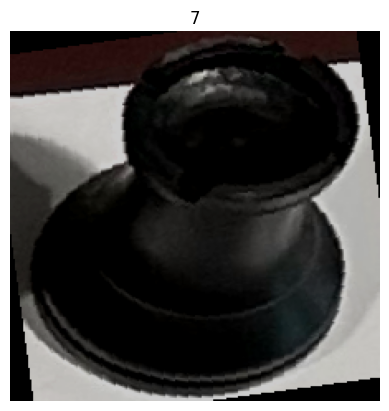

In [4]:
import torch
import matplotlib.pyplot as plt

mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

img = image.clone()
img = img.permute(1,2,0)
img = img * std + mean
img = img.clamp(0,1)

plt.imshow(img)
plt.title(label)
plt.axis("off")

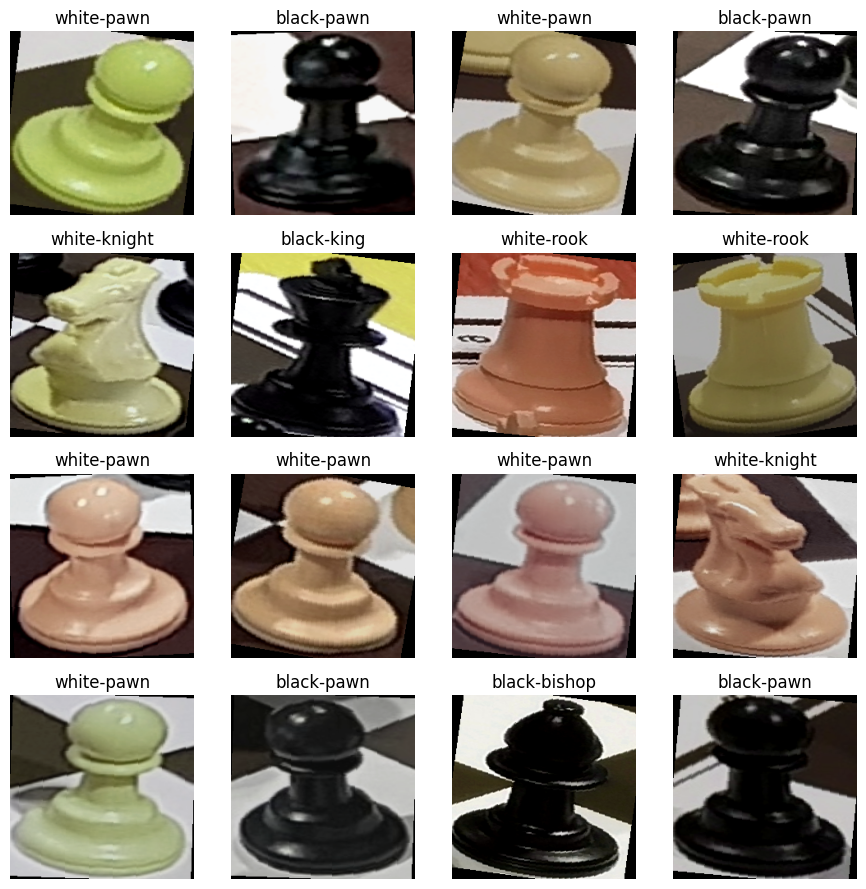

In [5]:
from piece_dataset import CATEGORIES

mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4

for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]

    # Unnormalize
    img = img.permute(1, 2, 0)
    img = img * std + mean
    img = img.clamp(0, 1)

    fig.add_subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(CATEGORIES[int(label)])
    plt.axis("off")

plt.tight_layout()

In [6]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(train_data, # dataset to turn into iterable
    batch_size=BATCH_SIZE, # how many samples per batch?
    shuffle=True # shuffle data every epoch?
)

val_dataloader = DataLoader(val_data,
    batch_size = BATCH_SIZE,
    shuffle = False
)


test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # don't necessarily have to shuffle the testing data
)

# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, val_dataloader,  test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of val dataloader: {len(val_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7a8674f200b0>, <torch.utils.data.dataloader.DataLoader object at 0x7a8675a64260>, <torch.utils.data.dataloader.DataLoader object at 0x7a8675167c20>)
Length of train dataloader: 961 batches of 32
Length of val dataloader: 192 batches of 32
Length of test dataloader: 197 batches of 32


In [7]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

In [8]:
from torch import nn
# Building a baseline model

flatten_model = nn.Flatten()


# Get a single sample
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x)

# Print out what happened
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")



Shape before flattening: torch.Size([3, 224, 224]) -> [color_channels, height, width]
Shape after flattening: torch.Size([3, 50176]) -> [color_channels, height*width]


In [9]:
from torch import nn
class ChessModelV0(nn.Module):
  def __init__(self, input_shape : int, hidden_units: int, output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_shape, out_features=hidden_units),
        nn.Linear(in_features = hidden_units, out_features=output_shape)

    )

  def forward(self,x):
    return self.layer_stack(x)


In [10]:
torch.manual_seed(42)

# Setup model with input parameters

model_0 = ChessModelV0(input_shape = 150528, hidden_units = 30, output_shape = len(CATEGORIES))

model_0.to("cpu")


ChessModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=150528, out_features=30, bias=True)
    (2): Linear(in_features=30, out_features=12, bias=True)
  )
)

In [11]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [12]:
# Import accuracy metric
from helper_functions import accuracy_fn # Note: could also use torchmetrics.Accuracy(task = 'multiclass', num_classes=len(class_names)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # this is also called "criterion"/"cost function" in some places
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [18]:
from timeit import default_timer as timer
def print_train_time(start:float, end:float, device: torch.device = None):
  """Prints difference between start and end time.
  Args:
      start (float): Start time of computation
      end (float): End time of computation
      device ([type], optional): Device that compute is running on. Default is None.

  Returns :
      float: time between start and end in seconds
  """
  total_time = end-start
  print(f"Train time on {device} : {total_time:.3f} seconds")
  return total_time

In [20]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs (we'll keep this small for faster training times)
epochs = 3

# Create training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    ### Training
    train_loss = 0
    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        # 1. Forward pass
        y_pred = model_0(X)

        # 2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulatively add up the loss per epoch

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Print out how many samples have been seen
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Divide total train loss by length of train dataloader (average loss per batch per epoch)
    train_loss /= len(train_dataloader)

    ### Testing
    # Setup variables for accumulatively adding up loss and accuracy
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # 1. Forward pass
            test_pred = model_0(X)

            # 2. Calculate loss (accumulatively)
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per epoch

            # 3. Calculate accuracy (preds need to be same as y_true)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        # Calculations on test metrics need to happen inside torch.inference_mode()
        # Divide total test loss by length of test dataloader (per batch)
        test_loss /= len(test_dataloader)

        # Divide total accuracy by length of test dataloader (per batch)
        test_acc /= len(test_dataloader)

    ## Print out what's happening
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/30723 samples


KeyboardInterrupt: 